# Sprint 1: Data Understanding

## Projekt
Vorhersage von Gehaltsklassen in Stellenausschreibungen mit Daten der Bundesagentur für Arbeit

## Ziel von Sprint 1
In diesem Sprint werden die Datenquellen definiert. Außerdem werden erste Stellenanzeigen über die Jobsuche-API der Bundesagentur für Arbeit geladen und untersucht. Ziel ist es, zu prüfen, ob die Datenqualität ausreicht und ob sich aus den Stellenanzeigen später eine Gehaltsklasse ableiten lässt.

## Importe

In [317]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## Datenquelle

Für die Stellenanzeigen wird die Jobsuche-API der Bundesagentur für Arbeit verwendet.

In diesem Sprint werden zunächst mehrere Suchbegriffe genutzt, damit der Datensatz nicht nur aus einer einzigen Berufsgruppe besteht. So entsteht ein erster breiter Überblick über die verfügbaren Anzeigen.

In [318]:
API_KEY = "jobboerse-jobsuche"
BASE_URL = "https://rest.arbeitsagentur.de/jobboerse/jobsuche-service/pc/v4/app/jobs"

headers = {
    "X-API-Key": API_KEY
}

## Erste Datensammlung

Es werden mehrere Suchbegriffe verwendet, um verschiedene Berufsfelder abzudecken. Pro Suchbegriff werden mehrere Seiten geladen. Ziel ist noch nicht ein perfekter Enddatensatz, sondern ein erster Rohdatensatz für die Datenexploration.

In [319]:
search_terms = ["data", "marketing", "logistik", "verkauf", "software", "pflege"]

all_jobs = []

for term in search_terms:
    print("Lade Daten für:", term)

    for page in range(1, 4):
        params = {
            "was": term,
            "page": page,
            "size": 100
        }

        response = requests.get(BASE_URL, headers=headers, params=params)

        if response.status_code != 200:
            print("Fehler bei", term, "Seite", page, "Status:", response.status_code)
            continue

        data = response.json()
        jobs = data.get("stellenangebote", [])

        print("  Seite", page, "-", len(jobs), "Anzeigen")

        for job in jobs:
            all_jobs.append(job)

print("\nGesamtzahl geladener Rohdatensätze:", len(all_jobs))

Lade Daten für: data
  Seite 1 - 100 Anzeigen
  Seite 2 - 100 Anzeigen
  Seite 3 - 100 Anzeigen
Lade Daten für: marketing
  Seite 1 - 100 Anzeigen
  Seite 2 - 100 Anzeigen
  Seite 3 - 100 Anzeigen
Lade Daten für: logistik
  Seite 1 - 100 Anzeigen
  Seite 2 - 100 Anzeigen
  Seite 3 - 100 Anzeigen
Lade Daten für: verkauf
  Seite 1 - 100 Anzeigen
  Seite 2 - 100 Anzeigen
  Seite 3 - 100 Anzeigen
Lade Daten für: software
  Seite 1 - 100 Anzeigen
  Seite 2 - 100 Anzeigen
  Seite 3 - 100 Anzeigen
Lade Daten für: pflege
  Seite 1 - 100 Anzeigen
  Seite 2 - 100 Anzeigen
  Seite 3 - 100 Anzeigen

Gesamtzahl geladener Rohdatensätze: 1800


## Erster Blick auf die Rohdaten

Bevor die Daten in ein DataFrame überführt werden, wird ein einzelnes Job-Objekt betrachtet. So lässt sich erkennen, welche Felder in den Daten vorhanden sind.

In [320]:
if len(all_jobs) > 0:
    print("Beispielhafte Keys eines Job-Objekts:\n")
    print(all_jobs[0].keys())

Beispielhafte Keys eines Job-Objekts:

dict_keys(['beruf', 'titel', 'refnr', 'arbeitsort', 'arbeitgeber', 'aktuelleVeroeffentlichungsdatum', 'modifikationsTimestamp', 'eintrittsdatum', 'kundennummerHash'])


## Relevante Felder extrahieren

Für das weitere Projekt sind vor allem folgende Informationen interessant:

- Referenznummer der Anzeige
- Jobtitel
- Beruf
- Arbeitgeber
- Ort

Diese Felder werden aus den Rohdaten in ein tabellarisches Format überführt.

In [321]:
def get_nested_value(d, keys, default=None):
    value = d
    for key in keys:
        if isinstance(value, dict) and key in value:
            value = value[key]
        else:
            return default
    return value


rows = []

for job in all_jobs:
    row = {
        "id": job.get("refnr"),
        "titel": job.get("titel"),
        "beruf": job.get("beruf"),
        "arbeitgeber": job.get("arbeitgeber"),
        "eintrittsdatum": job.get("eintrittsdatum"),
        "aktuelleVeroeffentlichungsdatum": job.get("aktuelleVeroeffentlichungsdatum"),
        "ort": get_nested_value(job, ["arbeitsort", "ort"]),
        "region": get_nested_value(job, ["arbeitsort", "region"]),
        "plz": get_nested_value(job, ["arbeitsort", "plz"]),
        "land": get_nested_value(job, ["arbeitsort", "land"]),
    }
    rows.append(row)

df = pd.DataFrame(rows)

print("Form des DataFrames:", df.shape)
df.head()

Form des DataFrames: (1800, 10)


,id,titel,beruf,arbeitgeber,eintrittsdatum,aktuelleVeroeffentlichungsdatum,ort,region,plz,land
0,12265-500563_JB5112036-S,Data Engineer (m/w/d),Data Engineer,FERCHAU GmbH Niederlassung Bielefeld,2026-04-01,2026-04-01,Bielefeld,Nordrhein-Westfalen,33602,Deutschland
1,12265-500191_JB5110630-S,Data Engineer (m/w/d),Data Engineer,FERCHAU GmbH Niederlassung Rosenheim,2026-04-01,2026-03-31,"Engelsberg, Oberbayern",Bayern,84549,Deutschland
2,11949-17175125-S,Data Scientist,Data Scientist,IVM Technical Consultants Wien Ges.m.b.H.,2026-04-02,2026-04-01,Bezirk: Graz-Umgebung,NaN,NaN,Österreich
3,12117-28699084-YF-S,Data Engineer (m/w/d),Data Engineer,BTB Blockheizkraftwerks- Träger- und Betreiber...,2026-04-01,2026-04-01,Berlin,Berlin,10585,Deutschland
4,11949-17172996-S,Data Engineer,Data Engineer,PwC Transaction Services Wirtschaftsprüfung GmbH,2026-04-02,2026-03-31,"Wien,Donaustadt",Wien,1220,Österreich


## Erste Dateninspektion

Nun wird geprüft, wie der Datensatz aussieht, wie viele Zeilen und Spalten vorhanden sind und ob wichtige Felder viele fehlende Werte enthalten.

In [322]:
print(df.shape)
print()
print(df.info())

(1800, 10)

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   id                               1800 non-null   str  
 1   titel                            1800 non-null   str  
 2   beruf                            1794 non-null   str  
 3   arbeitgeber                      1799 non-null   str  
 4   eintrittsdatum                   1800 non-null   str  
 5   aktuelleVeroeffentlichungsdatum  1800 non-null   str  
 6   ort                              1773 non-null   str  
 7   region                           1774 non-null   str  
 8   plz                              1681 non-null   str  
 9   land                             1800 non-null   str  
dtypes: str(10)
memory usage: 140.8 KB
None


## Filtern nach Ländern
Da für die spätere Gehaltszuordnung der deutsche Entgeltatlas verwendet werden soll, filtern wir den Datensatz nach Ländern.

In [323]:
df["land"].value_counts(dropna=False)

land
Deutschland    1579
Österreich      217
Kroatien          1
Niederlande       1
Zypern            1
Schweiz           1
Name: count, dtype: int64

## Einschränkung auf Deutschland

Da für die spätere Gehaltszuordnung der deutsche Entgeltatlas verwendet werden soll, werden für die weitere Analyse nur Stellenanzeigen mit Arbeitsort in Deutschland berücksichtigt. Anzeigen aus anderen Ländern werden ausgeschlossen, um die Konsistenz zwischen Stellenanzeigen und externer Gehaltsquelle sicherzustellen.

In [324]:
df = df[df["land"] == "Deutschland"].copy()
print(df.shape)
df["land"].value_counts(dropna=False)

(1579, 10)


land
Deutschland    1579
Name: count, dtype: int64

## Analyse fehlender Werte

In [325]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values

plz                                108
ort                                 27
region                              14
beruf                                6
arbeitgeber                          1
id                                   0
titel                                0
eintrittsdatum                       0
aktuelleVeroeffentlichungsdatum      0
land                                 0
dtype: int64

## Missing Value Handling
Fehlende Werte in id und beruf wurden als kritisch betrachtet, da diese Felder für die Identifikation der Anzeigen und die spätere Gehaltszuordnung zentral sind. Fehlende Werte in weniger kritischen Feldern wie Ort, Region oder Arbeitgeber wurden mit „Unbekannt“ ersetzt, um möglichst viele Anzeigen im Datensatz zu behalten.

In [326]:
df = df.dropna(subset=["id"]).copy()

df = df.dropna(subset=["beruf"]).copy()

df["titel"] = df["titel"].fillna("Unbekannt")
df["arbeitgeber"] = df["arbeitgeber"].fillna("Unbekannt")
df["ort"] = df["ort"].fillna("Unbekannt")
df["region"] = df["region"].fillna("Unbekannt")
df["plz"] = df["plz"].fillna("Unbekannt")
df["land"] = df["land"].fillna("Unbekannt")
df["eintrittsdatum"] = df["eintrittsdatum"].fillna("Unbekannt")
df["aktuelleVeroeffentlichungsdatum"] = df["aktuelleVeroeffentlichungsdatum"].fillna("Unbekannt")

In [327]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values

id                                 0
titel                              0
beruf                              0
arbeitgeber                        0
eintrittsdatum                     0
aktuelleVeroeffentlichungsdatum    0
ort                                0
region                             0
plz                                0
land                               0
dtype: int64

## Prüfung auf Duplikate

Da die Daten über mehrere Suchbegriffe geladen wurden, ist es möglich, dass dieselbe Stellenanzeige mehrfach vorkommt. Deshalb wird geprüft, wie viele doppelte IDs vorhanden sind.

In [328]:
print("Anzahl Zeilen insgesamt:", len(df))
print("Anzahl eindeutiger IDs:", df["id"].nunique())
print("Anzahl Duplikate:", len(df) - df["id"].nunique())

Anzahl Zeilen insgesamt: 1573
Anzahl eindeutiger IDs: 1573
Anzahl Duplikate: 0


In [329]:
df = df.drop_duplicates(subset="id").copy()
print(df.shape)

(1573, 10)


## Erste Exploration wichtiger Felder

Zur ersten Orientierung werden einige Häufigkeiten untersucht, zum Beispiel für Beruf, Ort und Titel.

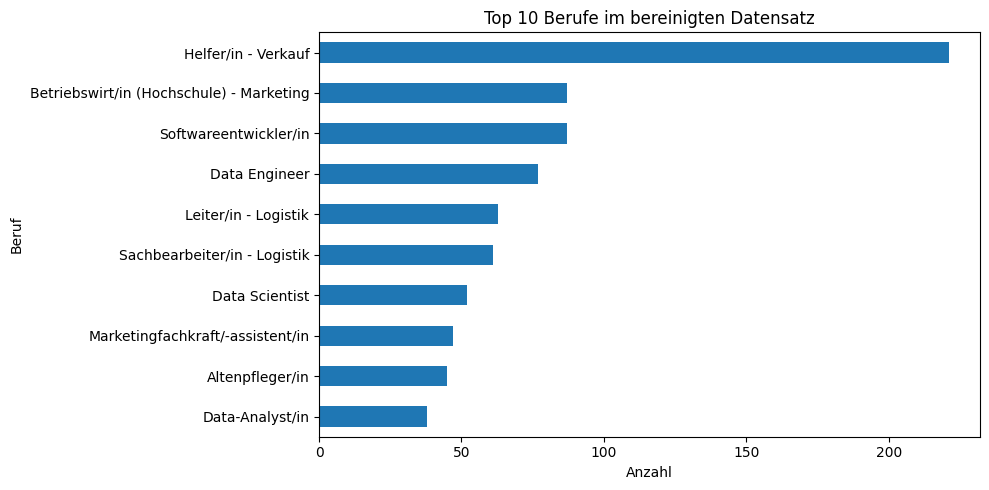

In [330]:
top_berufe = df["beruf"].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_berufe.sort_values().plot(kind="barh")
plt.title("Top 10 Berufe im bereinigten Datensatz")
plt.xlabel("Anzahl")
plt.ylabel("Beruf")
plt.tight_layout()
plt.show()

### Beruf

In [331]:
df["beruf"].value_counts(dropna=False).head(15)

beruf
Helfer/in - Verkauf                         221
Softwareentwickler/in                        87
Betriebswirt/in (Hochschule) - Marketing     87
Data Engineer                                77
Leiter/in - Logistik                         63
Sachbearbeiter/in - Logistik                 61
Data Scientist                               52
Marketingfachkraft/-assistent/in             47
Altenpfleger/in                              45
Data-Analyst/in                              38
Software-Architect                           28
Altenpflegehelfer/in                         28
Informatiker/in                              26
Fachkraft - Logistik/Materialwirtschaft      26
Leiter/in - Marketing                        23
Name: count, dtype: int64

### Ort

In [332]:
df["ort"].value_counts(dropna=False).head(15)

ort
Berlin                     50
München                    44
Hamburg                    35
Bremen                     32
Köln                       30
Frankfurt am Main          29
Unbekannt                  27
Stuttgart                  23
Kassel, Hessen             21
Dresden                    20
Nürnberg, Mittelfranken    20
Hannover                   18
Kiel                       14
Leipzig                    14
Düsseldorf                 14
Name: count, dtype: int64

### Titel

In [333]:
df["titel"].value_counts(dropna=False).head(15)

titel
Studentenjob Verkauf (m/w/d)              82
Schülerpraktikant im Verkauf (m/w/d)      81
Marketing Manager (m/w/d)                 39
Data Engineer (m/w/d)                     32
Teamleiter Logistik (m/w/d)               32
Sachbearbeiter Logistik (m/w/d)           29
Software Engineer (m/w/d)                 28
Aushilfe im Verkauf (m/w/d)               19
Data Analyst (m/w/d)                      15
Data Scientist (m/w/d)                    15
Minijob / Aushilfe Verkauf (m/w/d)        14
Mitarbeiter Logistik (m/w/d)              12
Software Tester (m/w/d)                   11
Pflegefachkraft (m/w/d) Junge Pflege       9
Nachwuchsführungskraft Verkauf (m/w/d)     8
Name: count, dtype: int64

In [334]:
df[["titel", "beruf", "ort"]].head(5)

,titel,beruf,ort
0,Data Engineer (m/w/d),Data Engineer,Bielefeld
1,Data Engineer (m/w/d),Data Engineer,"Engelsberg, Oberbayern"
3,Data Engineer (m/w/d),Data Engineer,Berlin
7,Data Analyst (m/w/d),Data-Analyst/in,Frankfurt am Main
8,Data Engineer (m/w/d),Data Scientist,Kiel


## Erste Einschätzung zur späteren Zielvariablen

Da die Datensammlung über ausgewählte Suchbegriffe erfolgte, stellt der Rohdatensatz keine vollständige oder repräsentative Abbildung des gesamten Stellenmarktes dar, sondern eine projektbezogene Stichprobe.

In diesem Projekt soll später nicht das echte Gehalt einer einzelnen Stellenanzeige vorhergesagt werden, sondern eine Gehaltsklasse als Proxy für das zu erwartende Gehaltsniveau.

Dafür ist entscheidend, ob die Stellenanzeigen Informationen enthalten, die später mit einem externen Gehaltswert verknüpft werden können. Besonders wichtig erscheinen hier:

- Beruf
- Jobtitel
- Ort bzw. Region

Besonders relevant ist die Berufsangabe, da sie voraussichtlich die wichtigste Verbindung zu externen Gehaltsdaten darstellt. Jobtitel sowie Orts- und Regionsangaben können diese Zuordnung zusätzlich verfeinern. Im nächsten Sprint wird geprüft, wie sich über Berufsangaben und externe Gehaltsdaten eine Gehaltsklasse als Zielvariable konstruieren lässt.

Der in Sprint 1 erzeugte Datensatz enthält 1 573 bereinigte und auf Deutschland eingeschränkte Stellenanzeigen und bildet die Grundlage für den Aufbau der Zielvariable in Sprint 2.

In [336]:
df.to_csv("../data/jobs_sprint1_cleaned.csv", index=False)
print("Datensatz gespeichert als jobs_sprint1_cleaned.csv")

Datensatz gespeichert als jobs_sprint1_cleaned.csv
